# 🚀 Model 13 — XGBoost No-PCA Super Feature Engineering (Stable Build)

**Goal:** Reach 90/90 Precision/Recall by replacing PCA with high-impact relational and frequency-based features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, roc_auc_score, confusion_matrix

print("Loading Original Unbalanced Data...")
train = pd.read_csv('../data/train_unbalanced.csv')
test = pd.read_csv('../data/test.csv')

y_train = train['isFraud']
y_test = test['isFraud']

DROP_COLS = ['isFraud', 'TransactionID']
X_train = train.drop(columns=[c for c in DROP_COLS if c in train.columns])
X_test = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

print(f"Initial Features: {X_train.shape[1]}")

Loading Original Unbalanced Data...


Initial Features: 226


In [2]:
def advanced_behavioral_fe(df_tr, df_te):
    X_tr = df_tr.copy()
    X_te = df_te.copy()
    
    # 1. Frequency Encoding
    for col in ['card1', 'addr1', 'P_emaildomain']:
        if col in X_tr.columns:
            mapping = X_tr[col].value_counts().to_dict()
            X_tr[f'{col}_freq'] = X_tr[col].map(mapping)
            X_te[f'{col}_freq'] = X_te[col].map(mapping).fillna(0)
            
    # 2. Amount Deviation
    if 'card1' in X_tr.columns and 'TransactionAmt' in X_tr.columns:
        mapping_mean = X_tr.groupby('card1')['TransactionAmt'].mean().to_dict()
        X_tr['Amt_to_Mean_Card1'] = X_tr['TransactionAmt'] / X_tr['card1'].map(mapping_mean)
        X_te['Amt_to_Mean_Card1'] = X_te['TransactionAmt'] / X_te['card1'].map(mapping_mean)
        
    # 3. Log Transform
    X_tr['TransactionAmt_Log'] = np.log1p(X_tr['TransactionAmt'])
    X_te['TransactionAmt_Log'] = np.log1p(X_te['TransactionAmt'])
    
    # Clean up any Infs or massive NaNs
    X_tr.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_te.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_tr.fillna(-1, inplace=True)
    X_te.fillna(-1, inplace=True)
    
    return X_tr, X_te

X_train_super, X_test_super = advanced_behavioral_fe(X_train, X_test)

In [3]:
imbalance = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300, 
    max_depth=8, 
    learning_rate=0.05, 
    scale_pos_weight=imbalance, 
    tree_method='approx', # Stable for memory
    n_jobs=-1, 
    random_state=42
)

print("Training Stable Super-XGBoost...")
model.fit(X_train_super, y_train)

probs = model.predict_proba(X_test_super)[:, 1]
preds = model.predict(X_test_super)

Training Stable Super-XGBoost...



--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    113975
           1       0.32      0.83      0.46      4133

    accuracy                           0.93    118108
   macro avg       0.66      0.88      0.71    118108
weighted avg       0.97      0.93      0.95    118108

PR-AUC: 0.7117


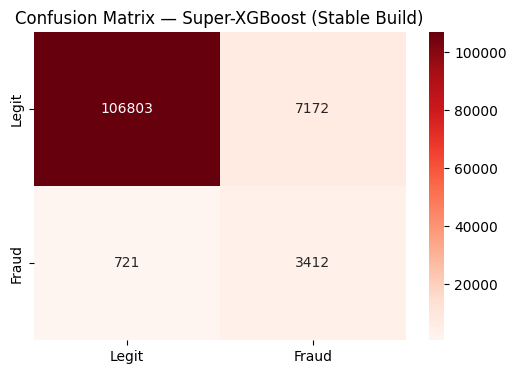

In [4]:
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, preds))

pr, rc, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(rc, pr)
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Super-XGBoost (Stable Build)')
plt.show()